In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np

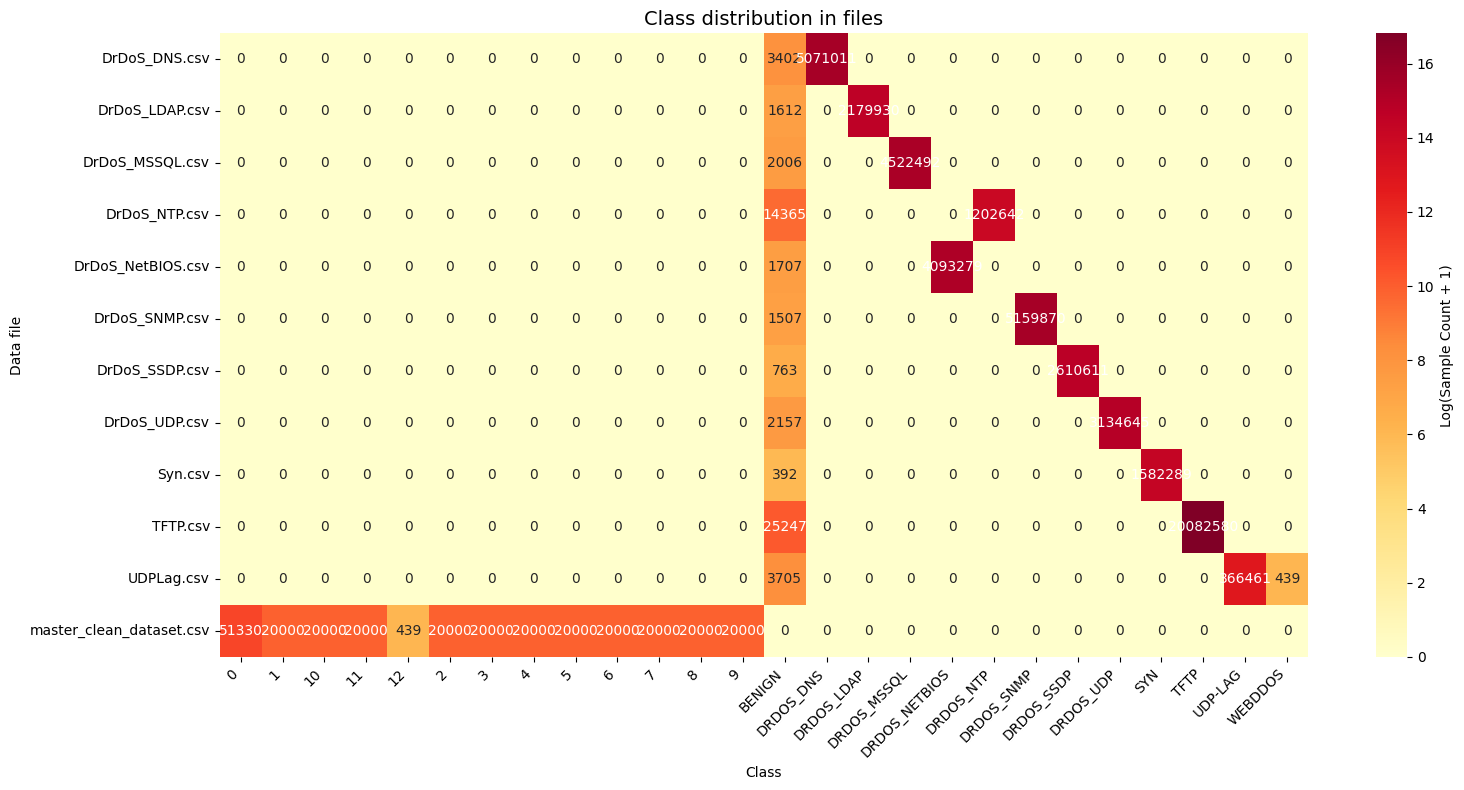

Class,0,1,10,11,12,2,3,4,5,6,...,DRDOS_MSSQL,DRDOS_NETBIOS,DRDOS_NTP,DRDOS_SNMP,DRDOS_SSDP,DRDOS_UDP,SYN,TFTP,UDP-LAG,WEBDDOS
File,,,,,,,,,,,,,,,,,,,,,
DrDoS_DNS.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DrDoS_LDAP.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DrDoS_MSSQL.csv,0,0,0,0,0,0,0,0,0,0,...,4522492,0,0,0,0,0,0,0,0,0
DrDoS_NTP.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,1202642,0,0,0,0,0,0,0
DrDoS_NetBIOS.csv,0,0,0,0,0,0,0,0,0,0,...,0,4093279,0,0,0,0,0,0,0,0
DrDoS_SNMP.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,5159870,0,0,0,0,0,0
DrDoS_SSDP.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2610611,0,0,0,0,0
DrDoS_UDP.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3134645,0,0,0,0
Syn.csv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1582289,0,0,0


In [2]:
def analyze_per_file_distribution(dir_path: str) -> pd.DataFrame:
    results = []
    for filename in sorted(os.listdir(dir_path)):
        if filename.endswith(".csv"):
            file_path = os.path.join(dir_path, filename)

            temp_cols = pd.read_csv(file_path, nrows=0).columns
            label_cols = [col for col in temp_cols if col.strip().lower() == "label"]

            if not label_cols:
                print(f"! Skipped {filename} - label column not found")
                print(f"! Skipped {filename} - label column not found")
                continue

            label_col_name: str = label_cols[0]
            df_labels: pd.DataFrame = pd.read_csv(file_path, usecols=[label_col_name])
            clean_labels: pd.Series = df_labels[label_col_name].astype("str").str.strip().str.upper()

            counts = clean_labels.value_counts()
            for label, count in counts.items():
                results.append({"File": filename, "Class": label, "Count": count})

    df_results = pd.DataFrame(results)
    pivot_df = df_results.pivot(index="File", columns="Class", values="Count").fillna(0).astype(int)


    plt.figure(figsize=(16, 8))
    sns.heatmap(np.log1p(pivot_df), annot=pivot_df, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Log(Sample Count + 1)'})
    plt.title("Class distribution in files", fontsize=14)
    plt.ylabel("Data file")
    plt.xlabel("Class")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return pivot_df


DATA_DIR: str = "../data"
analyze_per_file_distribution(DATA_DIR)